# Experiment 1: compare the three selection conditions

The comparison is novelty alone, novelty plus a randomly initialized observer, and novelty plus a pretrained observer. Each observer predicts hidden regions of **current images**; no offspring value is predicted.

Run the full pilot from the repository root:

```sh
uv run --extra imagenet python experiments/compare_selection.py --device mps --output runs/experiment1-pilot-mps
```

Defaults: seeds 7, 8, 9; 100 decisions; 96×96 rendering; mutation strength 0.2; topology changes enabled; comprehension weight 0.5; 20 training updates of batch size 16. Each run has a fresh strategy. The script retains failures and writes a report including all nine final selections. Existing output directories are rejected.

This notebook reads an existing comparison by default. The flags below must be changed explicitly to launch new runs.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import json

from IPython.display import display, Markdown
from PIL import Image
from automated_picbreeder.selection_comparison import run_comparison, write_comparison_report
from automated_picbreeder.selection_diagnostics import run_observer_diagnostics, inspect_common_grids

root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root.parent
comparison_dir = root / "runs" / "experiment1-pilot-mps"
DEVICE = "mps"  # Use "cpu" without Apple GPU access.
RUN_COMPARISON = False

if RUN_COMPARISON:
    run_comparison(output_dir=comparison_dir, cache_dir=root / ".cache" / "imagenet", device=DEVICE)
if not (comparison_dir / "comparison.json").exists():
    raise FileNotFoundError("Run the comparison command above, or point comparison_dir at an existing batch.")
report = write_comparison_report(comparison_dir)
print("Report:", comparison_dir / "REPORT.md")
print("Status:", report["status"])


Report: /Users/caminmccluskey/projects/conjective/automated-picbreeder/runs/experiment1-pilot-mps/REPORT.md
Status: complete


## Every final selection

Rows are seeds and columns are conditions. These are final endpoints, not the highest-scoring image found at any earlier step. Failed or pending runs remain visible. Scores are relative to each grid and cannot establish increasing absolute interestingness.

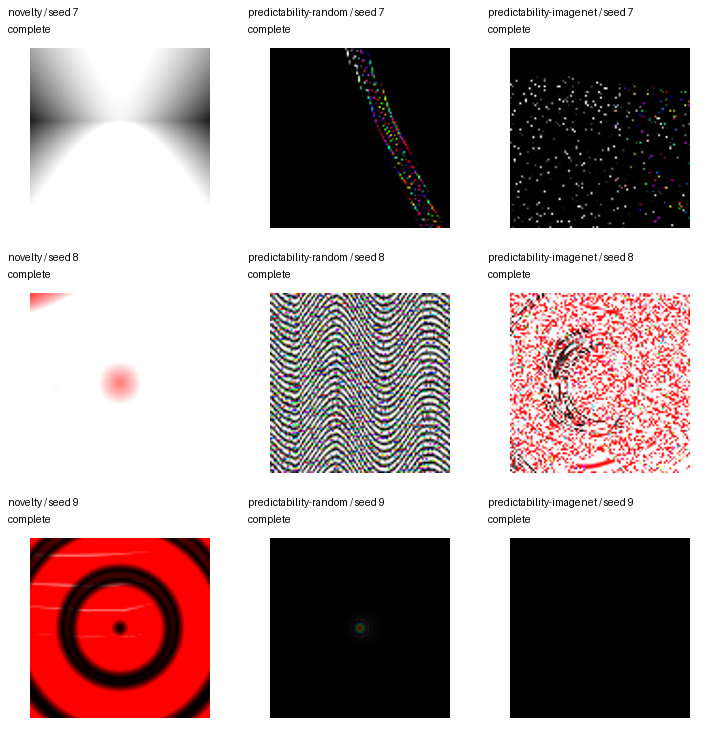

| condition | seed | status | selected_repeat_rate | parent_retention_rate | mean_fresh_masked_mse | selected_pairwise_pixel_mse | elapsed_seconds |
| --- | --- | --- | --- | --- | --- | --- | --- |
| novelty | 7 | complete | 0.0303 | 0.0101 | — | 0.3751 | 71.86 |
| predictability-random | 7 | complete | 0.0101 | 0.0101 | 0.01587 | 0.09213 | 113.4 |
| predictability-imagenet | 7 | complete | 0.0404 | 0.0303 | 0.02078 | 0.1204 | 128.5 |
| novelty | 8 | complete | 0.0303 | 0.0303 | — | 0.3672 | 74.99 |
| predictability-random | 8 | complete | 0 | 0 | 0.01598 | 0.221 | 130.2 |
| predictability-imagenet | 8 | complete | 0 | 0 | 0.03276 | 0.2104 | 127.8 |
| novelty | 9 | complete | 0.0202 | 0 | — | 0.3829 | 67.46 |
| predictability-random | 9 | complete | 0.2222 | 0.2121 | 0.007643 | 0.000403 | 120.7 |
| predictability-imagenet | 9 | complete | 0.3636 | 0.3131 | 0.0132 | 0.0003386 | 114.8 |

In [2]:
display(Image.open(comparison_dir / "final-images.png"))
columns = ("condition", "seed", "status", "selected_repeat_rate", "parent_retention_rate",
           "mean_fresh_masked_mse", "selected_pairwise_pixel_mse", "elapsed_seconds")
def formatted(value):
    return "—" if value is None else (f"{value:.4g}" if isinstance(value, float) else str(value))
lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
for row in report["runs"]:
    lines.append("| " + " | ".join(formatted(row.get(c)) for c in columns) + " |")
display(Markdown("\n".join(lines)))


Repeat rate counts selected images encountered in any earlier grid, including rejected candidates. Parent retention is a narrower measure. Both exclude the initial decision.

Fresh-image MSE excludes repeats and unavailable first-grid values. Independent runs see different images, so their errors do not isolate initialization effects. Novelty-only has no prediction error. Pairwise pixel MSE compares all selected images, including repeats, using the same post-run metric for every condition. It may reward colour shifts or noise.

In [3]:
# A predetermined seed for closer inspection; all seeds remain in the summary above.
INSPECT_SEED = 7
with (comparison_dir / "trajectories.csv").open() as handle:
    trajectory = list(csv.DictReader(handle))
for condition in ("novelty", "predictability-random", "predictability-imagenet"):
    print("\n", condition, "seed", INSPECT_SEED)
    for point in trajectory:
        step = int(point["decision"])
        if point["condition"] == condition and int(point["seed"]) == INSPECT_SEED and (step == 1 or step % 10 == 0):
            print("decision", step, "novelty", point["selected_novelty"],
                  "fresh MSE", point["fresh_masked_mse"], "repeated", point["selected_seen_before"])
    print("Full grids:", comparison_dir / f"{condition}-seed{INSPECT_SEED}" / "grids")



 novelty seed 7
decision 1 novelty  fresh MSE  repeated False
decision 10 novelty 0.04956048971186822 fresh MSE  repeated False
decision 20 novelty 0.1525335176848024 fresh MSE  repeated False
decision 30 novelty 0.1072118863204323 fresh MSE  repeated False
decision 40 novelty 0.23759018877792157 fresh MSE  repeated False
decision 50 novelty 0.20079594636872677 fresh MSE  repeated False
decision 60 novelty 0.17307406926163776 fresh MSE  repeated False
decision 70 novelty 0.15719070621700407 fresh MSE  repeated False
decision 80 novelty 0.3581648647924601 fresh MSE  repeated False
decision 90 novelty 0.27102597943598733 fresh MSE  repeated False
decision 100 novelty 0.0827037691619017 fresh MSE  repeated False
Full grids: /Users/caminmccluskey/projects/conjective/automated-picbreeder/runs/experiment1-pilot-mps/novelty-seed7/grids

 predictability-random seed 7
decision 1 novelty  fresh MSE  repeated False
decision 10 novelty 0.041249632838854404 fresh MSE 0.026951526291668415 repeated 

## Separate learning and identical-exposure diagnostics

The synthetic check trains on one seeded set of flat colours, gradients, patterns and noise, then scores a distinct held-out set. It also reports a simple visible-region-mean filling baseline. The common-grid check feeds the same recorded grids to each strategy regardless of its choices, isolating exposure from evolutionary divergence.

These small checks do not rank methods by human interestingness. Regenerating them creates a fresh directory; it does not modify the comparison runs.

{'initialization': 'random', 'updates': 0, 'family': 'flat', 'masked_mse': 0.060973276694615684, 'mean_fill_mse': 5.5264436297641464e-15}
{'initialization': 'random', 'updates': 0, 'family': 'gradient', 'masked_mse': 0.034537696900467076, 'mean_fill_mse': 0.008539688618232807}
{'initialization': 'random', 'updates': 0, 'family': 'pattern', 'masked_mse': 0.046230324233571686, 'mean_fill_mse': 0.01816478216399749}
{'initialization': 'random', 'updates': 0, 'family': 'noise', 'masked_mse': 0.09719414512316386, 'mean_fill_mse': 0.0829494372010231}
{'initialization': 'random', 'updates': 40, 'family': 'flat', 'masked_mse': 0.04807494580745697, 'mean_fill_mse': 5.5264436297641464e-15}
{'initialization': 'random', 'updates': 40, 'family': 'gradient', 'masked_mse': 0.024171122039357822, 'mean_fill_mse': 0.008539688618232807}
{'initialization': 'random', 'updates': 40, 'family': 'pattern', 'masked_mse': 0.03501498575011889, 'mean_fill_mse': 0.01816478216399749}
{'initialization': 'random', 'upd

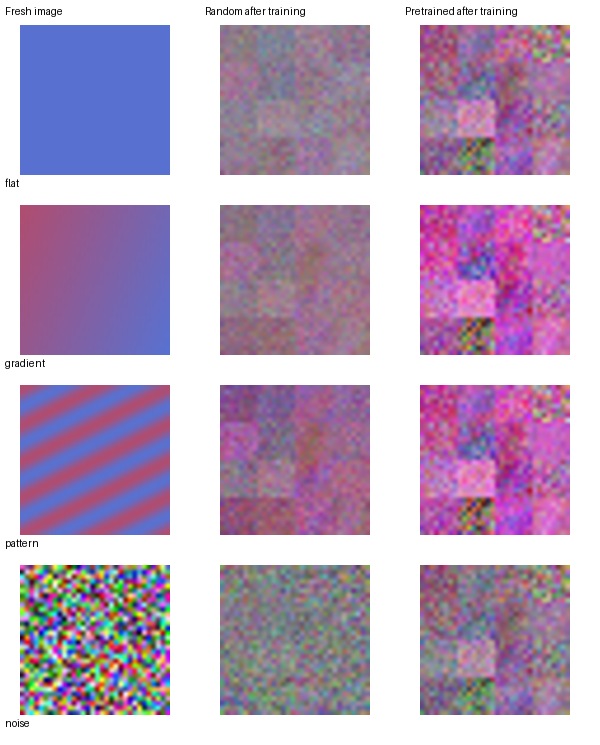

Held-out report: /Users/caminmccluskey/projects/conjective/automated-picbreeder/runs/phase3-diagnostics-mps/heldout/REPORT.md
Identical exposure, not independent breeding trajectories. Choices do not determine subsequent grids.
grid | condition | selected position (1-based) | fresh-image masked MSE
1 | novelty | 1 | —
2 | novelty | 7 | —
3 | novelty | 4 | —
4 | novelty | 9 | —
5 | novelty | 8 | —
1 | random | 1 | —
2 | random | 1 | 0.1441
3 | random | 4 | 0.1468
4 | random | 3 | 0.1045
5 | random | 5 | 0.08408
1 | imagenet | 1 | —
2 | imagenet | 4 | 0.1578
3 | imagenet | 9 | 0.1897
4 | imagenet | 3 | 0.1549
5 | imagenet | 4 | 0.1005
Common-grid report: /Users/caminmccluskey/projects/conjective/automated-picbreeder/runs/phase3-diagnostics-mps/common-grids/REPORT.md


In [4]:
diagnostic_dir = root / "runs" / "phase3-diagnostics-mps"
RUN_DIAGNOSTICS = False
if RUN_DIAGNOSTICS:
    diagnostic_dir = root / "runs" / ("diagnostics-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S-%fZ"))
    diagnostic_dir.mkdir()
    run_observer_diagnostics(output_dir=diagnostic_dir / "heldout", cache_dir=root / ".cache" / "imagenet", device=DEVICE)
    inspect_common_grids(comparison_dir / "novelty-seed7" / "session.json",
                         output_dir=diagnostic_dir / "common-grids", cache_dir=root / ".cache" / "imagenet", device=DEVICE)
if (diagnostic_dir / "heldout/diagnostics.json").exists():
    diagnostics = json.loads((diagnostic_dir / "heldout/diagnostics.json").read_text())
    for row in diagnostics["rows"]:
        print(row)
    display(Image.open(diagnostic_dir / "heldout/predictions.png"))
    print("Held-out report:", diagnostic_dir / "heldout/REPORT.md")
if (diagnostic_dir / "common-grids/common-grids.json").exists():
    common = json.loads((diagnostic_dir / "common-grids/common-grids.json").read_text())
    print(common["interpretation"])
    print("grid | condition | selected position (1-based) | fresh-image masked MSE")
    for row in common["rows"]:
        meta = row["metadata"]
        errors = ([error for error, seen in zip(meta["masked_mse"], meta["seen_before"])
                   if not seen] if meta.get("comprehension_available") else [])
        error = sum(errors) / len(errors) if errors else None
        print(row["decision"], row["condition"], row["position"] + 1, formatted(error), sep=" | ")
    print("Common-grid report:", diagnostic_dir / "common-grids/REPORT.md")


The experiment concerns current-image novelty and predictability. Learning progress, future offspring value, and CPPN representation assessment are separate experiments. Review failures and complete trajectories alongside attractive outputs.